# LLooM Analysis: Inciting Speech False Negatives & False Positives

This notebook applies the LLooM pipeline to analyze misclassified samples from the INCITE dataset:

- **False Negatives (FN):** Gold = Inciting (Identity/Imputed Misdeeds/Exhortation), Predicted = None
- **False Positives (FP):** Gold = None, Predicted = Inciting (Identity/Imputed Misdeeds/Exhortation)

Pipeline: **Distill → Embed → Cluster → Synthesize Concepts → Score → Visualize**

Uses the OpenAI Chat Completions API. Set **`OPENAI_API_KEY`** before running. Models: **gpt-3.5-turbo** (distill + score), **gpt-5-mini** (synthesize concepts only).

In [2]:
!pip install -q -U requests pandas scikit-learn sentence-transformers umap-learn hdbscan tqdm wordcloud squarify networkx


In [4]:
import re, json, os, time, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from wordcloud import WordCloud
import squarify

API_URL = "https://api.openai.com/v1/chat/completions"



/Users/vishnu/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load Inciting JSONL and extract FN / FP texts (binary combined)

In [5]:
JSONL_PATH = "../Binary-Classification Run Zero-Shot/inciting_combined.jsonl"  # binary zero-shot combined file

OUTPUT_DIR = "outputs/lloom_inciting_combined"
os.makedirs(OUTPUT_DIR, exist_ok=True)

MODEL_DISTILL = "gpt-3.5-turbo"
MODEL_SYNTH = "gpt-5-mini"
MODEL_SCORE = "gpt-3.5-turbo"

INCITING_LABELS = {"Identity", "Imputed Misdeeds", "Exhortation"}

FN_SEED = (
    "patterns in inciting speech that evades detection, including subtle identity "
    "attacks, veiled accusations of misdeeds, and indirect exhortations to act against "
    "target groups"
)
FP_SEED = (
    "patterns in non-inciting content that gets falsely flagged as inciting, including "
    "factual reporting, counter-speech, and contextual misinterpretation of group "
    "references"
)

def load_jsonl(path):
    records = []
    with open(path, "r") as f:
        content = f.read()
    decoder = json.JSONDecoder()
    idx = 0
    while idx < len(content):
        while idx < len(content) and content[idx] in " \t\n\r":
            idx += 1
        if idx >= len(content):
            break
        obj, end_idx = decoder.raw_decode(content, idx)
        records.append(obj)
        idx = end_idx
    return records


def derive_pred_label(rec):
    """Derive a single predicted label from binary-style flags.

    Priority order: Identity > Imputed Misdeeds > Exhortation.
    If none of the three are positive, return "None".
    """
    if rec.get("pred_identity") == "Identity":
        return "Identity"
    if rec.get("pred_imputed_misdeeds") == "Imputed Misdeeds":
        return "Imputed Misdeeds"
    if rec.get("pred_exhortation") == "Exhortation":
        return "Exhortation"
    return "None"


records = load_jsonl(JSONL_PATH)
print(f"Total records: {len(records)}")

fn_texts, fp_texts = [], []
for rec in records:
    gold = rec.get("gold_label", "")
    pred = derive_pred_label(rec)
    text = rec.get("text", "")
    if not text:
        continue

    gold_is_inciting = gold in INCITING_LABELS
    pred_is_inciting = pred in INCITING_LABELS

    # Class-centric FN/FP for "Inciting" using binary-combined predictions
    if gold_is_inciting and not pred_is_inciting:
        fn_texts.append(text)
    elif (not gold_is_inciting) and pred_is_inciting:
        fp_texts.append(text)

print(f"FN_inciting (gold inciting, pred non-inciting): {len(fn_texts)}")
print(f"FP_inciting (gold non-inciting, pred inciting): {len(fp_texts)}")

Total records: 7000
FN_inciting (gold inciting, pred non-inciting): 190
FP_inciting (gold non-inciting, pred inciting): 2934


# Helper functions

In [6]:
def clean_text(x):
    x = str(x).lower().strip()
    x = re.sub(r"http\S+|www\S+", " ", x)
    x = re.sub(r"&amp;|amp", " ", x)
    x = re.sub(r">+", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

def safe_json_load(text):
    text = str(text).strip()
    text = re.sub(r"^```json\s*", "", text)
    text = re.sub(r"^```\s*", "", text)
    text = re.sub(r"\s*```$", "", text)
    try:
        return json.loads(text)
    except Exception:
        pass
    m = re.search(r"\{.*\}", text, re.DOTALL)
    if m:
        return json.loads(m.group(0))
    raise ValueError(f"Could not parse JSON from response:\n{text[:1200]}")

def _openai_chat_raw(prompt: str, model_name: str, temperature: float | None) -> str:
    api_key = os.environ.get("OPENAI_API_KEY")
    if not api_key:
        raise RuntimeError("Set OPENAI_API_KEY (e.g. export OPENAI_API_KEY=sk-...)")
    headers = {"Authorization": f"Bearer {api_key}", "Content-Type": "application/json"}
    payload = {
        "model": model_name,
        "messages": [{"role": "user", "content": prompt}],
        "response_format": {"type": "json_object"},
    }
    if model_name.startswith("gpt-5") or model_name.startswith("o1") or model_name.startswith("o3"):
        payload["max_completion_tokens"] = 4096
        if model_name.startswith("gpt-5"):
            payload["seed"] = 42
    else:
        payload["max_tokens"] = 4096
        if temperature is not None:
            payload["temperature"] = temperature
    resp = requests.post(API_URL, headers=headers, json=payload, timeout=120)
    if resp.status_code != 200:
        try:
            err = resp.json()
            msg = err.get("error", {}).get("message", str(err))
            typ = err.get("error", {}).get("type", "unknown")
            raise RuntimeError(f"API Error {resp.status_code} ({typ}): {msg}")
        except (ValueError, KeyError):
            raise RuntimeError(f"API Error {resp.status_code}: {resp.text[:500]}")
    return resp.json()["choices"][0]["message"]["content"]

def openai_chat_json(prompt, model_name, temperature=0.2):
    # gpt-5-mini and similar models do not support the temperature parameter
    if model_name.startswith("gpt-5") or model_name.startswith("o1") or model_name.startswith("o3"):
        temperature = None
    text = _openai_chat_raw(prompt, model_name, temperature)
    return safe_json_load(text)


# Step 1: Distill texts into bullets

In [7]:
def distill_text_to_bullets(text, seed_phrase=""):
    prompt = f"""
You will read one social media text and summarize its main points into 2 to 4 short bullet phrases.

Rules:
- Each bullet must be 5 to 10 words
- Focus on the most salient meaning
- Avoid generic phrases
- Avoid repeating the same idea
- Keep wording concise
- Use the analytic focus only as a lens, not as a reason to invent content
- Return valid JSON only

Analytic focus:
{seed_phrase if seed_phrase else "None"}

Return format:
{{
  "bullets": ["...", "..."]
}}

TEXT:
{text}
"""
    obj = openai_chat_json(prompt, MODEL_DISTILL, temperature=0.2)
    bullets = obj.get("bullets", [])
    bullets = [str(b).strip() for b in bullets if str(b).strip()]
    return bullets[:4]

def _distill_one(idx, txt, seed_phrase="", max_retries=3, sleep_seconds=2):
    for attempt in range(max_retries):
        try:
            bullets = distill_text_to_bullets(txt, seed_phrase=seed_phrase)
            return {"orig_index": idx, "text": txt, "bullets": bullets, "error": None}
        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep(sleep_seconds * (attempt + 1))
            else:
                return {"orig_index": idx, "text": txt, "bullets": None, "error": str(e)}

def run_distillation(texts, seed_phrase="", max_workers=4, checkpoint_path="checkpoint.jsonl"):
    rows, done_ids = [], set()
    if os.path.exists(checkpoint_path):
        with open(checkpoint_path, "r") as f:
            for line in f:
                rec = json.loads(line)
                rows.append(rec)
                done_ids.add(rec["orig_index"])

    items = [(i, t) for i, t in enumerate(texts) if i not in done_ids]
    print(f"Already completed: {len(done_ids)}, Remaining: {len(items)}")

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {
            executor.submit(_distill_one, idx, txt, seed_phrase): idx
            for idx, txt in items
        }
        with open(checkpoint_path, "a") as fout:
            for fut in tqdm(as_completed(futures), total=len(futures), desc="Distilling"):
                result = fut.result()
                fout.write(json.dumps(result) + "\n")
                fout.flush()
                rows.append(result)
    return pd.DataFrame(rows)

In [8]:
fn_distilled_raw = run_distillation(
    fn_texts,
    seed_phrase=FN_SEED,
    max_workers=4,
    checkpoint_path=f"{OUTPUT_DIR}/fn_distill_checkpoint.jsonl",
)
fp_distilled_raw = run_distillation(
    fp_texts,
    seed_phrase=FP_SEED,
    max_workers=4,
    checkpoint_path=f"{OUTPUT_DIR}/fp_distill_checkpoint.jsonl",
)
print("FN distilled:", fn_distilled_raw.shape)
print("FP distilled:", fp_distilled_raw.shape)

Already completed: 0, Remaining: 190


Distilling: 100%|██████████| 190/190 [00:39<00:00,  4.82it/s]


Already completed: 0, Remaining: 2934


Distilling: 100%|██████████| 2934/2934 [10:20<00:00,  4.73it/s]

FN distilled: (190, 4)
FP distilled: (2934, 4)


# Step 2: Expand bullets, embed, and cluster

In [9]:
def expand_distilled_rows(distilled_df):
    rows = []
    for _, row in distilled_df.iterrows():
        bullets = row.get("bullets")
        if isinstance(bullets, list):
            for b in bullets:
                rows.append({"orig_index": row["orig_index"], "text": row["text"], "bullet": b, "error": row.get("error")})
        else:
            rows.append({"orig_index": row["orig_index"], "text": row["text"], "bullet": None, "error": row.get("error")})
    return pd.DataFrame(rows)

fn_distilled = expand_distilled_rows(fn_distilled_raw).dropna(subset=["bullet"]).copy()
fp_distilled = expand_distilled_rows(fp_distilled_raw).dropna(subset=["bullet"]).copy()
fn_distilled = fn_distilled[fn_distilled["bullet"].astype(str).str.strip() != ""].reset_index(drop=True)
fp_distilled = fp_distilled[fp_distilled["bullet"].astype(str).str.strip() != ""].reset_index(drop=True)

print("Expanded FN bullets:", fn_distilled.shape)
print("Expanded FP bullets:", fp_distilled.shape)

fn_distilled.to_csv(f"{OUTPUT_DIR}/fn_distilled_bullets.csv", index=False)
fp_distilled.to_csv(f"{OUTPUT_DIR}/fp_distilled_bullets.csv", index=False)

Expanded FN bullets: (455, 4)
Expanded FP bullets: (7797, 4)


In [10]:
embedder = SentenceTransformer("all-mpnet-base-v2")


def embed_and_cluster(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """UMAP + HDBSCAN on bullet embeddings; safe for empty or tiny sets."""
    bullets = df["bullet"].astype(str).tolist()
    n = len(bullets)
    if n == 0:
        print(
            f"[SKIP {name}] No bullet rows — distillation may have failed (check API key, errors in distill checkpoint, or re-run distill)."
        )
        out = df.copy()
        out["cluster"] = np.empty(len(out), dtype=np.int64)
        return out
    emb = embedder.encode(bullets, show_progress_bar=True)
    if n == 1:
        out = df.copy()
        out["cluster"] = 0
        print(f"[{name}] Single bullet; assigned cluster 0 (UMAP/HDBSCAN skipped).")
        return out
    n_neighbors = min(15, max(2, n - 1))
    n_components = min(5, max(1, n - 1))
    umap_model = UMAP(
        n_neighbors=n_neighbors,
        n_components=n_components,
        min_dist=0.0,
        metric="cosine",
        random_state=42,
    )
    min_cs = min(12, max(2, n // 2))
    clusterer = HDBSCAN(
        min_cluster_size=min_cs,
        metric="euclidean",
        cluster_selection_method="eom",
        prediction_data=True,
    )
    red = umap_model.fit_transform(emb)
    out = df.copy()
    out["cluster"] = clusterer.fit_predict(red)
    print(f"{name} clusters:", out["cluster"].value_counts().head(15))
    return out


fn_distilled = embed_and_cluster(fn_distilled, "FN")
fp_distilled = embed_and_cluster(fp_distilled, "FP")

Batches: 100%|██████████| 15/15 [00:01<00:00,  9.62it/s]
/Users/vishnu/miniconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


FN clusters: cluster
-1     204
 10     47
 0      43
 1      24
 2      19
 9      19
 3      18
 8      18
 7      18
 4      16
 5      16
 6      13
Name: count, dtype: int64


Batches: 100%|██████████| 244/244 [00:14<00:00, 16.96it/s]
/Users/vishnu/miniconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


FP clusters: cluster
-1      3128
 0       232
 125     140
 114     135
 108     124
 42       95
 59       88
 116      82
 79       81
 16       79
 103      77
 3        70
 124      68
 104      68
 81       67
Name: count, dtype: int64


# Step 3: Synthesize concepts from clusters

In [11]:
def synthesize_concept(cluster_bullets, seed_phrase=""):
    bullets_text = "\n".join(f"- {b}" for b in cluster_bullets)
    prompt = f"""
You are a qualitative-analysis assistant.
Below are bullet-point summaries drawn from a single cluster of social media texts.
Propose ONE high-level concept that unifies these bullets.

Rules:
- concept_name: 3-8 word descriptive label
- description: 1-2 sentences explaining the concept
- inclusion_criteria: concrete criteria for deciding if a new text matches
- example_signals: 3 short phrases a matching text might contain

Analytic focus:
{seed_phrase if seed_phrase else "None"}

You must respond with valid json only (no markdown fences, no extra text).
Use this json object shape:
{{
  "concept_name": "...",
  "description": "...",
  "inclusion_criteria": "...",
  "example_signals": ["...", "...", "..."]
}}

BULLETS:
{bullets_text}
"""
    return openai_chat_json(prompt, MODEL_SYNTH)

def build_concepts(distilled_df, top_n=10, max_bullets=20, seed_phrase=""):
    concepts = []
    counts = distilled_df[distilled_df["cluster"] != -1]["cluster"].value_counts().head(top_n)
    for cid in tqdm(counts.index, desc="Synthesizing"):
        bullets = distilled_df[distilled_df["cluster"] == cid]["bullet"].dropna().tolist()[:max_bullets]
        try:
            c = synthesize_concept(bullets, seed_phrase=seed_phrase)
            c["cluster"], c["cluster_size"] = int(cid), int(counts[cid])
            concepts.append(c)
        except Exception as e:
            concepts.append({"cluster": int(cid), "cluster_size": int(counts[cid]),
                             "concept_name": None, "error": str(e)})
    return pd.DataFrame(concepts)

In [12]:
fn_concepts = build_concepts(fn_distilled, top_n=10, seed_phrase=FN_SEED)
fp_concepts = build_concepts(fp_distilled, top_n=10, seed_phrase=FP_SEED)

display(fn_concepts)
display(fp_concepts)

fn_concepts.to_csv(f"{OUTPUT_DIR}/fn_concepts.csv", index=False)
fp_concepts.to_csv(f"{OUTPUT_DIR}/fp_concepts.csv", index=False)

Synthesizing: 100%|██████████| 10/10 [01:52<00:00, 11.27s/it]


,concept_name,description,inclusion_criteria,example_signals,cluster,cluster_size
0,Veiled Incitement and Indirect Exhortations,Content that covertly urges action against peo...,Matches if the text (1) urges or endorses acti...,"[God will reward those who deal with them, Don...",10,47
1,Veiled Accusation and Indirect Incitement,"Speech that insinuates wrongdoing, disloyalty,...",Text that (a) levels an allegation or moral at...,"[accepted as a slave, revenge by Godhra, they ...",0,43
2,Veiled Identity Attacks and Incitement,Subtle rhetorical strategies that delegitimize...,The text uses sarcasm or rhetorical questions ...,"[Sarcastic 'doubting your religion?' question,...",1,24
3,Victimhood Framing with Implicit Retribution,Accounts that catalog attacks on religious com...,Text centralizes recent or historical attacks ...,"[they attacked our temples, remember the Sri L...",2,19
4,Veiled Dehumanizing Incitement to Violence,Posts that identify a target group and use deh...,Text must (1) identify or clearly imply a targ...,"[They're vermin — time to cleanse, Meet them a...",9,19
5,Coded Communal Mobilization Rhetoric,"Speech that subtly mobilizes, defends, or dele...",Matches when a text (a) explicitly references ...,"[Jihad and Mal-e-Ghanimat, congratulations to ...",3,18
6,Covert Religious Identity Attacks,"Subtle, indirect messaging that targets people...",Text that (1) focuses on a group's religious/i...,"[Not a real Muslim, Too cowardly to stand with...",8,18
7,Veiled Identity-Based Incitement,Indirect hostile messaging that targets religi...,Text must (a) reference a protected identity (...,"[They're not truly Indian, Don't drink tea at ...",7,18
8,Veiled Mob Incitement Through Victim Narratives,Posts that recount violent incidents and graph...,Matches if the text meets at least two of the ...,"[suspected thieves stole cattle, burning and l...",4,16
9,Demographic replacement and political takeover...,Rhetoric that highlights the growth and electo...,"Mentions of population percentages, growth pro...",[Muslim population to increase to 26.4% by 203...,5,16


,concept_name,description,inclusion_criteria,example_signals,cluster,cluster_size
0,Contextual Group Reference Misclassification,Non-inciting posts that mention or analyze gro...,Text names or refers to one or more groups but...,"[reported that members of X said..., quoting: ...",0,232
1,Contextualized Discussion of Jihad and Terrorism,"Analytical, explanatory, or critical reference...",Text discusses jihad/terrorism/Islamic texts o...,"[explains jihad from Islamic texts, questions ...",125,140
2,Contextual critique of Islamic texts,Analytical or critical discussion of Islamic b...,Contains critical or questioning language abou...,"[quoting Quranic verse (e.g., ‘fight in the wa...",114,135
3,Contextual Reporting on Kashmiri Pandits,"Texts that document historical events, displac...",Includes factual or historical accounts about ...,"[forced displacement of Kashmiri Hindus, recre...",108,124
4,Contextual Temple Conversion Reporting,Neutral factual or first-person accounts descr...,"Mentions temples, idols, archaeological sites,...",[historical temple unearthed after Muslim rule...,42,95
5,Protective reporting on alleged interfaith tar...,Factual or cautionary posts that report or war...,Text refers to alleged harm or targeting of a ...,"[forcibly converted, protect Hindu girls, targ...",59,88
6,Factual Reporting About Hindu Incidents,Posts that neutrally report or critique incide...,"Text references Hindu communities, specific in...","[Hindu exodus from Kairana, media exaggerate i...",116,82
7,Accusations That Congress Endangers Hindus,Critical or reporting statements that allege t...,Contains an explicit reference to 'Congress' o...,"[Congress endangering safety of Hindus, shelte...",79,81
8,Contextual Reporting Misclassified as Incitement,Factual or critical accounts that describe his...,"Text discusses a marginalized group (e.g., Dal...","[persecution of Dalits in Pakistan, Dalits fal...",16,79
9,Contextualized intergroup accusation reporting,Neutral or factual reporting that relays alleg...,"Text that (a) reports allegations, investigati...","[security agencies warn of infiltrators, accus...",103,77


# Step 4: Score every FN/FP text against concepts

In [13]:
def score_text_against_concepts(text, concepts_df):
    valid = concepts_df.dropna(subset=["concept_name", "inclusion_criteria"])
    block = [f"Concept: {c['concept_name']}\nCriteria: {c['inclusion_criteria']}" for _, c in valid.iterrows()]
    prompt = f"""
You will read one social media text and decide which concepts apply.

Return valid JSON only in this format:
{{
  "matches": [
    {{"concept_name": "...", "match": 0, "reason": "short reason"}}
  ]
}}

Important:
- Include one entry for every concept provided
- Use match = 1 only if the text clearly fits the concept criteria
- Otherwise use match = 0

Concepts:
{chr(10).join(block)}

TEXT:
{text}
"""
    return openai_chat_json(prompt, MODEL_SCORE, temperature=0.1)["matches"]

def _score_one(idx, txt, concepts_df, max_retries=3, sleep_seconds=2):
    for attempt in range(max_retries):
        try:
            matches = score_text_against_concepts(txt, concepts_df)
            return {"orig_index": idx, "text": txt, "matches": matches, "error": None}
        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep(sleep_seconds * (attempt + 1))
            else:
                return {"orig_index": idx, "text": txt, "matches": None, "error": str(e)}

def score_dataset(texts, concepts_df, max_workers=4, checkpoint_path="score_ckpt.jsonl"):
    rows, done_ids = [], set()
    if os.path.exists(checkpoint_path):
        with open(checkpoint_path, "r") as f:
            for line in f:
                rec = json.loads(line)
                rows.append(rec)
                done_ids.add(rec["orig_index"])

    items = [(i, t) for i, t in enumerate(texts) if i not in done_ids]
    print(f"Already scored: {len(done_ids)}, Remaining: {len(items)}")

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {executor.submit(_score_one, idx, txt, concepts_df): idx for idx, txt in items}
        with open(checkpoint_path, "a") as fout:
            for fut in tqdm(as_completed(futures), total=len(futures), desc="Scoring"):
                result = fut.result()
                fout.write(json.dumps(result) + "\n")
                fout.flush()
                rows.append(result)
    return pd.DataFrame(rows)

In [14]:
fn_scores_raw = score_dataset(
    fn_texts,
    fn_concepts,
    max_workers=4,
    checkpoint_path=f"{OUTPUT_DIR}/fn_score_checkpoint.jsonl",
)
fp_scores_raw = score_dataset(
    fp_texts,
    fp_concepts,
    max_workers=4,
    checkpoint_path=f"{OUTPUT_DIR}/fp_score_checkpoint.jsonl",
)

def expand_scored_rows(scored_df):
    rows = []
    for _, row in scored_df.iterrows():
        matches = row.get("matches")
        if isinstance(matches, list):
            for m in matches:
                rows.append({
                    "orig_index": row["orig_index"],
                    "text": row["text"],
                    "concept_name": m.get("concept_name"),
                    "match": m.get("match"),
                    "reason": m.get("reason"),
                    "error": row.get("error"),
                })
        else:
            rows.append({
                "orig_index": row["orig_index"],
                "text": row["text"],
                "concept_name": None,
                "match": None,
                "reason": None,
                "error": row.get("error"),
            })
    return pd.DataFrame(rows)

fn_scores = expand_scored_rows(fn_scores_raw)
fp_scores = expand_scored_rows(fp_scores_raw)

fn_scores.to_csv(f"{OUTPUT_DIR}/fn_scores.csv", index=False)
fp_scores.to_csv(f"{OUTPUT_DIR}/fp_scores.csv", index=False)

print("FN scores:", fn_scores.shape)
print("FP scores:", fp_scores.shape)

Already scored: 0, Remaining: 190


Scoring: 100%|██████████| 190/190 [02:02<00:00,  1.55it/s]


Already scored: 0, Remaining: 2934


Scoring: 100%|██████████| 2934/2934 [30:50<00:00,  1.59it/s] 

FN scores: (958, 6)
FP scores: (14512, 6)


# Step 5: Visualizations

In [15]:
def summarize_concept_coverage(scores_df):
    matched = scores_df[scores_df["match"] == 1].copy()
    by_concept = matched["concept_name"].value_counts().reset_index()
    by_concept.columns = ["concept_name", "matched_count"]
    return by_concept

fn_summary = summarize_concept_coverage(fn_scores)
fp_summary = summarize_concept_coverage(fp_scores)

fn_summary.to_csv(f"{OUTPUT_DIR}/fn_concept_summary.csv", index=False)
fp_summary.to_csv(f"{OUTPUT_DIR}/fp_concept_summary.csv", index=False)

display(fn_summary)
display(fp_summary)

,concept_name,matched_count
0,Veiled Identity Attacks and Incitement,121
1,Veiled Identity-Based Incitement,75
2,Covert Religious Identity Attacks,61
3,Victimhood Framing with Implicit Retribution,39
4,Veiled Accusation and Indirect Incitement,30
5,Veiled Mob Incitement Through Victim Narratives,30
6,Coded Communal Mobilization Rhetoric,18
7,Demographic replacement and political takeover...,17
8,Veiled Dehumanizing Incitement to Violence,10
9,Veiled Incitement and Indirect Exhortations,9


,concept_name,matched_count
0,Factual Reporting About Hindu Incidents,1627
1,Contextual Reporting Misclassified as Incitement,786
2,Contextual critique of Islamic texts,733
3,Contextualized Discussion of Jihad and Terrorism,657
4,Contextualized intergroup accusation reporting,422
5,Contextual Group Reference Misclassification,410
6,Accusations That Congress Endangers Hindus,388
7,Protective reporting on alleged interfaith tar...,217
8,Contextual Reporting on Kashmiri Pandits,190
9,Contextual Temple Conversion Reporting,145


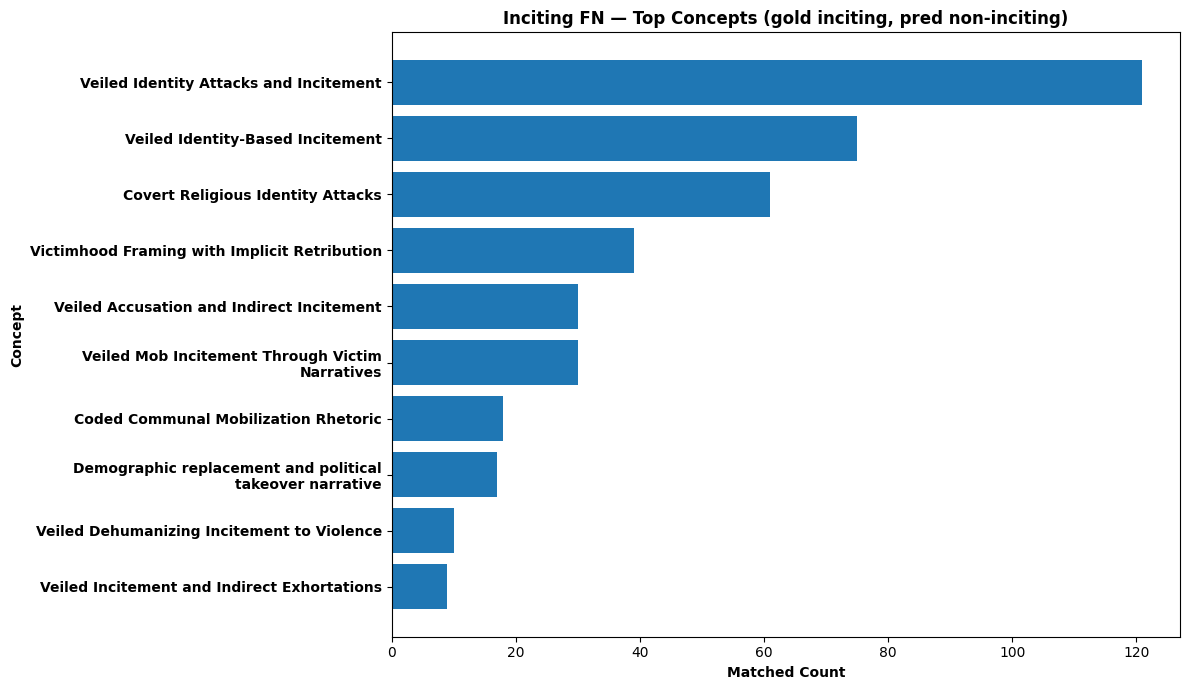

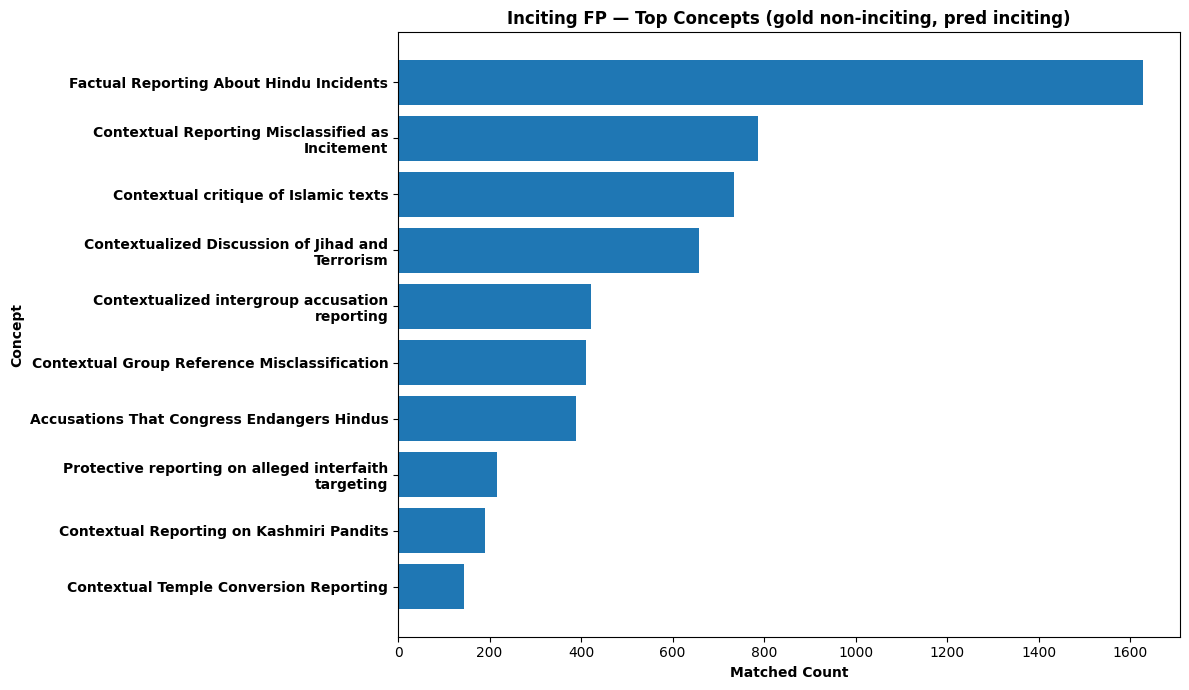

In [16]:
def wrap_labels(labels, width=40):
    return ["\n".join(textwrap.wrap(str(l), width=width)) for l in labels]

def concept_barplot(df, title, top_n=10, save_path=None):
    plot_df = df.sort_values("matched_count", ascending=False).head(top_n).iloc[::-1]
    wrapped = wrap_labels(plot_df["concept_name"], width=45)
    plt.figure(figsize=(12, 7))
    plt.barh(wrapped, plot_df["matched_count"])
    plt.yticks(fontweight="bold")
    plt.xlabel("Matched Count", fontweight="bold")
    plt.ylabel("Concept", fontweight="bold")
    plt.title(title, fontweight="bold")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()

concept_barplot(
    fn_summary,
    "Inciting FN — Top Concepts (gold inciting, pred non-inciting)",
    save_path=f"{OUTPUT_DIR}/fn_concepts_barplot.pdf",
)

concept_barplot(
    fp_summary,
    "Inciting FP — Top Concepts (gold non-inciting, pred inciting)",
    save_path=f"{OUTPUT_DIR}/fp_concepts_barplot.pdf",
)

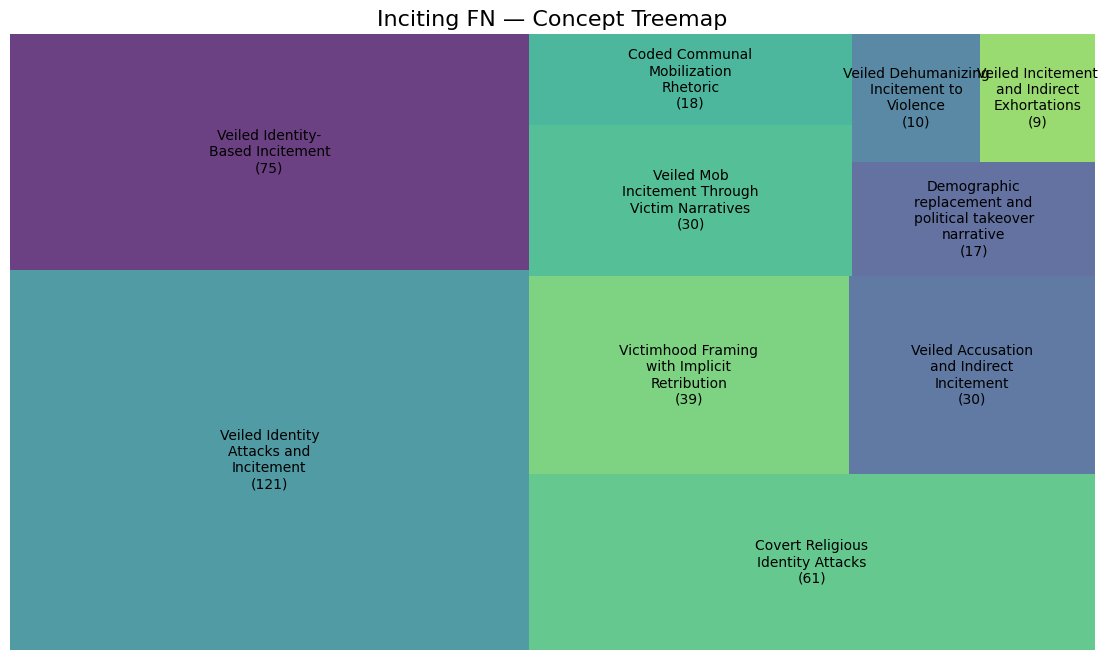

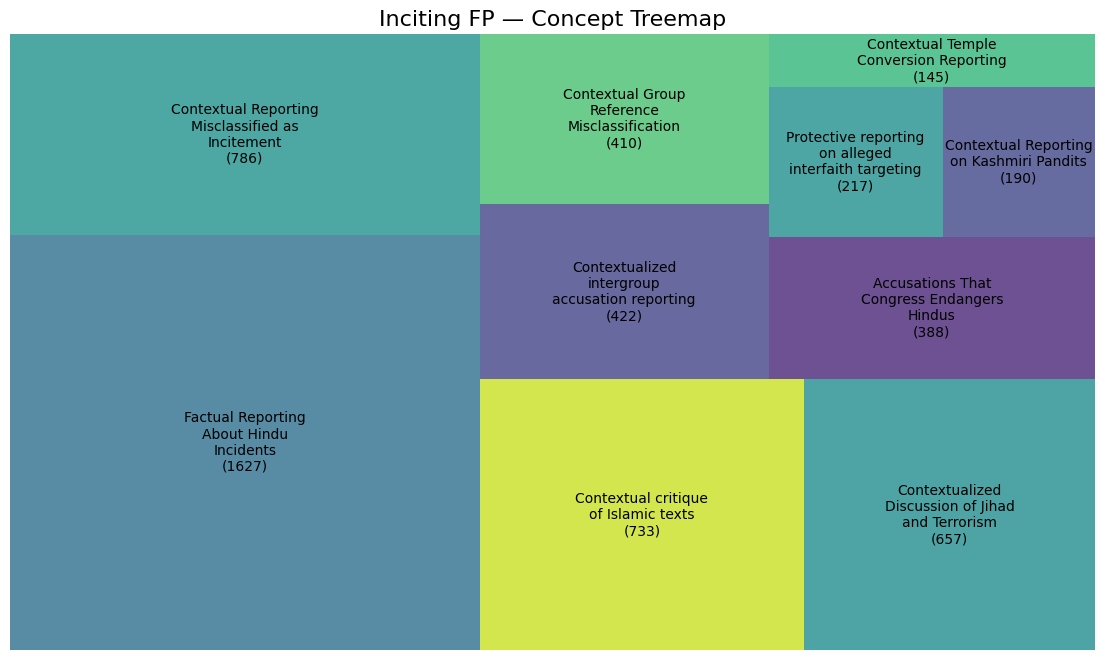

In [17]:
def concept_treemap(df, title, top_n=10):
    plot_df = df.sort_values("matched_count", ascending=False).head(top_n)
    labels = ["\n".join(textwrap.wrap(str(n), width=20)) + f"\n({c})"
              for n, c in zip(plot_df["concept_name"], plot_df["matched_count"])]
    plt.figure(figsize=(14, 8))
    squarify.plot(sizes=plot_df["matched_count"], label=labels, alpha=0.8)
    plt.axis("off")
    plt.title(title, fontsize=16)
    plt.show()

concept_treemap(fn_summary, "Inciting FN — Concept Treemap")
concept_treemap(fp_summary, "Inciting FP — Concept Treemap")

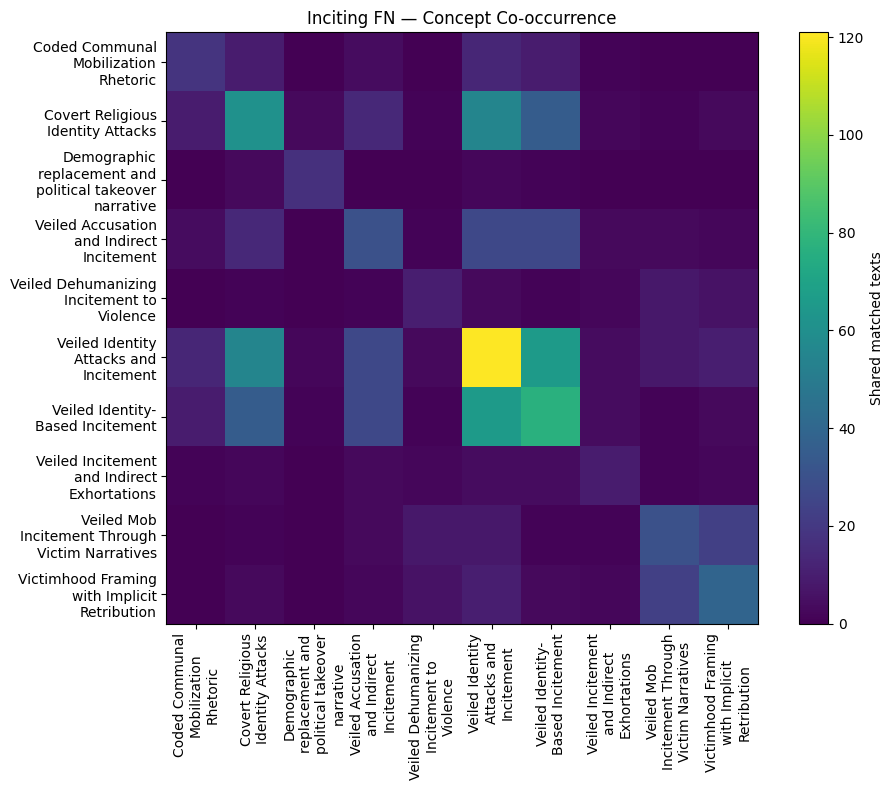

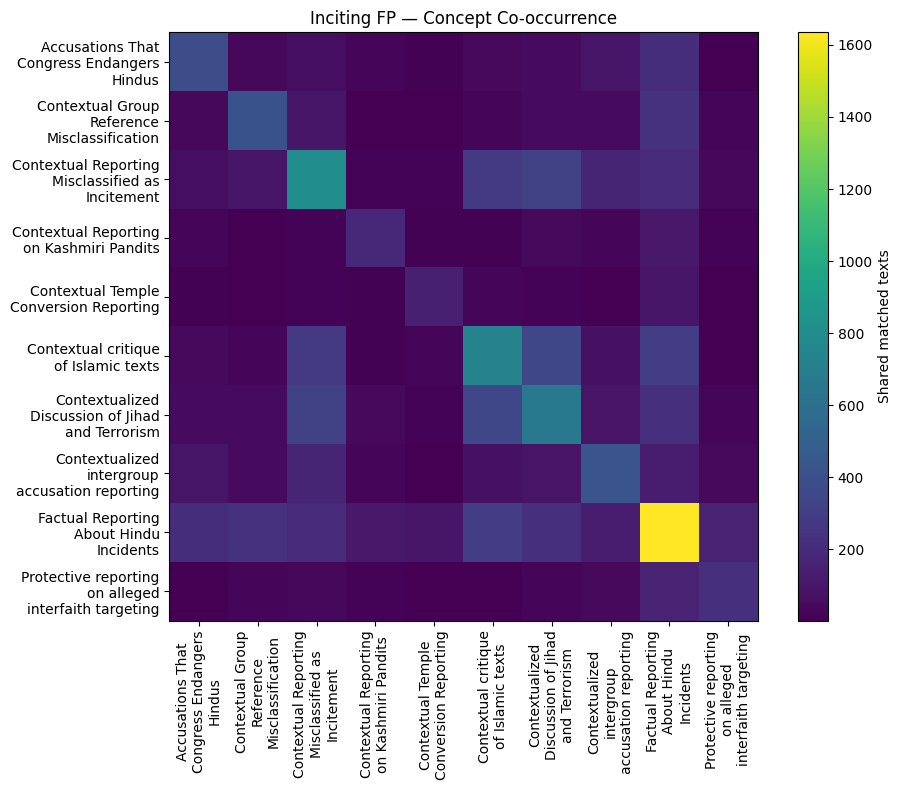

In [18]:
def concept_cooccurrence_heatmap(scores_df, title, top_n=10):
    matched = scores_df[scores_df["match"] == 1].copy()
    top_concepts = matched["concept_name"].value_counts().head(top_n).index.tolist()
    matched = matched[matched["concept_name"].isin(top_concepts)]
    binary = pd.crosstab(matched["orig_index"], matched["concept_name"])
    cooc = binary.T.dot(binary)
    plt.figure(figsize=(10, 8))
    plt.imshow(cooc, interpolation="nearest")
    plt.colorbar(label="Shared matched texts")
    plt.xticks(range(len(cooc.columns)), ["\n".join(textwrap.wrap(c, 20)) for c in cooc.columns], rotation=90)
    plt.yticks(range(len(cooc.index)), ["\n".join(textwrap.wrap(c, 20)) for c in cooc.index])
    plt.title(title)
    plt.tight_layout()
    plt.show()

concept_cooccurrence_heatmap(fn_scores, "Inciting FN — Concept Co-occurrence")
concept_cooccurrence_heatmap(fp_scores, "Inciting FP — Concept Co-occurrence")

In [19]:
print("All outputs saved to:", OUTPUT_DIR)
print("Files:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(f"  {f}")

All outputs saved to: outputs/lloom_inciting_combined
Files:
  fn_concept_summary.csv
  fn_concepts.csv
  fn_concepts_barplot.pdf
  fn_distill_checkpoint.jsonl
  fn_distilled_bullets.csv
  fn_score_checkpoint.jsonl
  fn_scores.csv
  fp_concept_summary.csv
  fp_concepts.csv
  fp_concepts_barplot.pdf
  fp_distill_checkpoint.jsonl
  fp_distilled_bullets.csv
  fp_score_checkpoint.jsonl
  fp_scores.csv
